# Capstone EDA: D4RL vs Minari HalfCheetah Dataset Comparison
**Project:** Eliminating the High-Risk Interaction Cost of Autonomous Robotics through Offline Sequence Modeling: A Decision Transformer Approach  
**Authors:** Darwin Juan, Dan Kast, David Terando  
**Date:** April 2026  

---

## Purpose
This notebook performs Exploratory Data Analysis (EDA) comparing the **D4RL HalfCheetah medium-expert** dataset against the equivalent **Minari** datasets (`halfcheetah-medium-v0` and `halfcheetah-expert-v0`). 

Our team will use the Minari datasets for training and modeling in MuJoCo. This comparison documents data quality, coverage, and structural equivalence between the two sources — a required artifact for our paper.

### Sections
1. Environment Setup & Imports  
2. Load D4RL Dataset  
3. Load and Combine Minari Datasets  
4. Dataset Structure Overview  
5. Return / Reward Analysis  
6. Episode Length Statistics  
7. Action Space Analysis (Saturation, Distribution)  
8. State Space Analysis  
9. State-Action Coverage Visualization  
10. Trajectory Quality Comparison  
11. Summary Statistics Table
12. Final Assessment

---
## Section 1: Environment Setup & Imports

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Imports and Configuration
#
# We import all libraries needed for data loading, processing, and visualization.
# numpy / pandas: numerical and tabular data handling
# matplotlib / seaborn: static plotting
# sklearn: PCA for dimensionality reduction in state-space visualization
# tqdm: progress bars for loops over large datasets
# warnings: suppress non-critical deprecation notices
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os
import sys

# ── Plot style ────────────────────────────────────────────────────────────────
# Using a clean academic style suitable for paper figures
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Color palette: D4RL = blue tones, Minari = orange/green tones
PALETTE = {
    'd4rl': '#2166AC',           # D4RL combined
    'minari_medium': '#F4A582',  # Minari medium
    'minari_expert': '#1A9850',  # Minari expert
    'minari_combined': '#D6604D' # Minari combined
}

print("✅ Imports successful.")
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

✅ Imports successful.
Python: 3.11.15 (main, Mar 25 2026, 02:58:47) [Clang 22.1.1 ]
NumPy: 2.4.4
Pandas: 3.0.2


---
## Section 2: Load D4RL Dataset

We load `halfcheetah-medium-expert-v2` from D4RL. This dataset is a 50/50 mix of medium-quality and expert-quality trajectories — the standard offline RL benchmark for this task.

> **Fallback:** If the `d4rl` package fails on Apple Silicon, we fall back to downloading the raw HDF5 file directly from the D4RL data server.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Load D4RL Dataset
#
# Strategy:
#   1. Try importing d4rl and gymnasium to load via the standard API
#   2. If that fails (common on Apple Silicon due to mujoco_py legacy deps),
#      fall back to downloading the raw HDF5 file directly.
#
# The dataset returned is a dict with keys:
#   observations, actions, rewards, terminals, timeouts, (infos)
# ─────────────────────────────────────────────────────────────────────────────

def load_d4rl_via_package():
    """Attempt to load D4RL via the d4rl package + gymnasium."""
    import gymnasium as gym
    import d4rl  # noqa: F401 — registers D4RL envs with gymnasium
    env = gym.make('halfcheetah-medium-expert-v2')
    dataset = env.get_dataset()
    env.close()
    return dataset


def load_d4rl_via_hdf5(cache_dir='./data'):
    """
    Fallback: Download the D4RL HDF5 file directly from the hosting server
    and parse it into the standard dict format.
    
    This avoids any dependency on the mujoco_py legacy package, which
    is not available for Apple Silicon arm64 natively.
    """
    import urllib.request
    import h5py

    os.makedirs(cache_dir, exist_ok=True)
    hdf5_path = os.path.join(cache_dir, 'halfcheetah_medium_expert-v2.hdf5')

    if not os.path.exists(hdf5_path):
        url = ('https://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/'
               'halfcheetah_medium_expert-v2.hdf5')
        print(f"Downloading D4RL HDF5 from:\n  {url}")
        print("This is ~150MB — please wait...")
        urllib.request.urlretrieve(url, hdf5_path,
            reporthook=lambda b, bs, t: print(f"  {min(100, int(b*bs/t*100))}%",
                                              end='\r') if t > 0 else None)
        print("\n✅ Download complete.")
    else:
        print(f"✅ Using cached file: {hdf5_path}")

    # Parse HDF5 into standard dict
    with h5py.File(hdf5_path, 'r') as f:
        dataset = {
            'observations': f['observations'][:],
            'actions':      f['actions'][:],
            'rewards':      f['rewards'][:],
            'terminals':    f['terminals'][:],
            'timeouts':     f['timeouts'][:] if 'timeouts' in f else
                            np.zeros(len(f['rewards'][:]), dtype=bool),
        }
    return dataset


# ── Main loading logic ────────────────────────────────────────────────────────
print("Loading D4RL HalfCheetah medium-expert-v2 dataset...")

try:
    d4rl_data = load_d4rl_via_package()
    print("✅ Loaded via d4rl package.")
except Exception as e:
    print(f"⚠️  d4rl package load failed ({e})")
    print("Falling back to direct HDF5 download...")
    d4rl_data = load_d4rl_via_hdf5()

print(f"\nD4RL dataset keys: {list(d4rl_data.keys())}")
print(f"  observations shape : {d4rl_data['observations'].shape}")
print(f"  actions shape      : {d4rl_data['actions'].shape}")
print(f"  rewards shape      : {d4rl_data['rewards'].shape}")

Loading D4RL HalfCheetah medium-expert-v2 dataset...
⚠️  d4rl package load failed (No module named 'd4rl')
Falling back to direct HDF5 download...
  https://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/halfcheetah_medium_expert-v2.hdf5
This is ~150MB — please wait...
  100%
✅ Download complete.

D4RL dataset keys: ['observations', 'actions', 'rewards', 'terminals', 'timeouts']
  observations shape : (2000000, 17)
  actions shape      : (2000000, 6)
  rewards shape      : (2000000,)


___
#### Troubleshooting
The D4RL package (rail-berkeley/d4rl) failed to install on the Apple Silicon arm64 architecture. The root cause was its dependency on pybullet v3.2.7, a physics simulation library that requires compilation from source with legacy C toolchains. The build process failed during native extension compilation:

error: command '/usr/bin/cc' failed with exit code 1  |  hint: pybullet (v3.2.7) was included because d4rl (v1.1) depends on pybullet

The Farama Foundation fork of D4RL was also attempted but produced the same pybullet compilation failure. As a result, the D4RL dataset was loaded via a direct HDF5 fallback: the raw halfcheetah_medium_expert-v2.hdf5 file (~150 MB) was downloaded directly from the RAIL Berkeley dataset server and parsed using the h5py library. This approach bypasses all d4rl package dependencies and produces an identical data structure.

---
## Section 3: Load and Combine Minari Datasets

Minari stores data as individual episodes in an HDF5-backed format. We load both:
- `halfcheetah-medium-v0` — medium-quality trajectories
- `halfcheetah-expert-v0` — expert-quality trajectories

We then concatenate them into a single flat dict that mirrors the D4RL structure, enabling apples-to-apples comparison.

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Load and Combine Minari Datasets
#
# Minari datasets are stored per-episode. We:
#   1. Download both datasets (Minari handles caching automatically)
#   2. Iterate over episodes to extract observations, actions, rewards
#   3. Track episode boundaries so we can compute per-episode stats later
#   4. Combine medium + expert into one flat array (mirrors D4RL structure)
#
# Note: Minari observations include an 'observation' key inside each step.
# ─────────────────────────────────────────────────────────────────────────────

import minari


def load_minari_dataset(dataset_id):
    """
    Download (if needed) and load a Minari dataset.
    Returns a dict with:
      observations, actions, rewards, terminals
      + episode_returns and episode_lengths for per-episode analysis.
    """
    print(f"  Loading Minari dataset: {dataset_id}")

    # minari.load_dataset downloads on first call, then uses local cache
    try:
        dataset = minari.load_dataset(dataset_id)
    except Exception:
        print(f"  Not found locally — downloading {dataset_id}...")
        minari.download_dataset(dataset_id)
        dataset = minari.load_dataset(dataset_id)

    all_obs, all_acts, all_rews, all_terms = [], [], [], []
    ep_returns, ep_lengths = [], []

    for episode in tqdm(dataset.iterate_episodes(),
                        total=dataset.total_episodes,
                        desc=f"  Parsing {dataset_id}",
                        leave=False):
        # episode.observations has shape (T+1, obs_dim) — first obs is initial state
        obs = episode.observations[:-1]  # drop the terminal observation
        acts = episode.actions
        rews = episode.rewards
        # terminals: True only on the last step if the episode ended (not timeout)
        terms = episode.terminations

        all_obs.append(obs)
        all_acts.append(acts)
        all_rews.append(rews)
        all_terms.append(terms)

        ep_returns.append(float(np.sum(rews)))
        ep_lengths.append(len(rews))

    return {
        'observations':    np.concatenate(all_obs, axis=0),
        'actions':         np.concatenate(all_acts, axis=0),
        'rewards':         np.concatenate(all_rews, axis=0),
        'terminals':       np.concatenate(all_terms, axis=0),
        'episode_returns': np.array(ep_returns),
        'episode_lengths': np.array(ep_lengths),
        'n_episodes':      len(ep_returns),
        'source_id':       dataset_id,
    }


# ── Load both Minari splits ───────────────────────────────────────────────────
print("Loading Minari datasets...")
minari_medium = load_minari_dataset('mujoco/halfcheetah/medium-v0')
minari_expert = load_minari_dataset('mujoco/halfcheetah/expert-v0')

# ── Combine into a single dataset (mirrors D4RL medium-expert structure) ──────
# D4RL medium-expert is a 50/50 concatenation of medium and expert trajectories.
# We replicate this by combining both Minari splits.
minari_combined = {
    'observations': np.concatenate([minari_medium['observations'],
                                     minari_expert['observations']], axis=0),
    'actions':      np.concatenate([minari_medium['actions'],
                                     minari_expert['actions']], axis=0),
    'rewards':      np.concatenate([minari_medium['rewards'],
                                     minari_expert['rewards']], axis=0),
    'terminals':    np.concatenate([minari_medium['terminals'],
                                     minari_expert['terminals']], axis=0),
    'episode_returns': np.concatenate([minari_medium['episode_returns'],
                                        minari_expert['episode_returns']]),
    'episode_lengths': np.concatenate([minari_medium['episode_lengths'],
                                        minari_expert['episode_lengths']]),
    'n_episodes':   minari_medium['n_episodes'] + minari_expert['n_episodes'],
}

print("\n✅ Minari datasets loaded and combined.")
print(f"  Medium  — {minari_medium['n_episodes']:,} episodes, "
      f"{len(minari_medium['observations']):,} timesteps")
print(f"  Expert  — {minari_expert['n_episodes']:,} episodes, "
      f"{len(minari_expert['observations']):,} timesteps")
print(f"  Combined— {minari_combined['n_episodes']:,} episodes, "
      f"{len(minari_combined['observations']):,} timesteps")

Loading Minari datasets...
  Loading Minari dataset: mujoco/halfcheetah/medium-v0


  Loading Minari dataset: mujoco/halfcheetah/expert-v0
  Not found locally — downloading mujoco/halfcheetah/expert-v0...



Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Dataset mujoco/halfcheetah/expert-v0 downloaded to /Users/djt/.minari/datasets/mujoco/halfcheetah/expert-v0



✅ Minari datasets loaded and combined.
  Medium  — 1,000 episodes, 1,000,000 timesteps
  Expert  — 1,000 episodes, 1,000,000 timesteps
  Combined— 2,000 episodes, 2,000,000 timesteps


___
#### Troubleshooting
When first attempting to download the Minari datasets, the following error was encountered:

ImportError: huggingface_hub is not installed. Please install it using pip install "minari[hf]"

Minari has migrated its dataset hosting infrastructure from the Farama Foundation’s own servers to Hugging Face Hub. The base minari package does not include the huggingface_hub client as a default dependency; it must be explicitly installed via the [hf] extras flag. Resolution: uv pip install "minari[hf]"


After resolving the Hugging Face dependency, a second error was encountered: the dataset IDs originally used in the notebook (halfcheetah-medium-v0 and halfcheetah-expert-v0) no longer existed on the Minari remote registry. A query of all available remote datasets revealed that the naming convention had changed to a namespaced format:

mujoco/halfcheetah/medium-v0 mujoco/halfcheetah/expert-v0 mujoco/halfcheetah/simple-v0

The notebook was updated to use mujoco/halfcheetah/medium-v0 and mujoco/halfcheetah/expert-v0 as the correct dataset identifiers. This namespace change reflects Minari’s broader reorganization of its dataset registry under environment-family prefixes.


---
## Section 4: Dataset Structure Overview

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: High-Level Structure Overview
#
# Build a summary DataFrame showing the basic shape and dimensionality of
# each dataset. This is Table 1 in the paper.
#
# The D4RL dataset does not natively store per-episode boundaries — we
# reconstruct episodes by detecting terminal/timeout flags.
# ─────────────────────────────────────────────────────────────────────────────

def extract_d4rl_episodes(dataset):
    """
    Reconstruct episode boundaries from D4RL terminal/timeout flags.
    Returns arrays of per-episode cumulative rewards and lengths.
    """
    terminals = dataset['terminals'].astype(bool)
    timeouts  = dataset.get('timeouts', np.zeros_like(terminals)).astype(bool)
    rewards   = dataset['rewards']

    episode_ends = np.where(terminals | timeouts)[0]
    ep_returns, ep_lengths = [], []
    start = 0

    for end in episode_ends:
        ep_returns.append(rewards[start:end+1].sum())
        ep_lengths.append(end - start + 1)
        start = end + 1

    return np.array(ep_returns), np.array(ep_lengths)


# Extract D4RL episodes
d4rl_ep_returns, d4rl_ep_lengths = extract_d4rl_episodes(d4rl_data)

# Build summary table
summary_rows = [
    {
        'Dataset':         'D4RL medium-expert-v2',
        'Total Timesteps': len(d4rl_data['rewards']),
        'Episodes':        len(d4rl_ep_returns),
        'Obs Dim':         d4rl_data['observations'].shape[1],
        'Action Dim':      d4rl_data['actions'].shape[1],
        'Mean Return':     d4rl_ep_returns.mean(),
        'Mean Ep Length':  d4rl_ep_lengths.mean(),
    },
    {
        'Dataset':         'Minari medium-v0',
        'Total Timesteps': len(minari_medium['rewards']),
        'Episodes':        minari_medium['n_episodes'],
        'Obs Dim':         minari_medium['observations'].shape[1],
        'Action Dim':      minari_medium['actions'].shape[1],
        'Mean Return':     minari_medium['episode_returns'].mean(),
        'Mean Ep Length':  minari_medium['episode_lengths'].mean(),
    },
    {
        'Dataset':         'Minari expert-v0',
        'Total Timesteps': len(minari_expert['rewards']),
        'Episodes':        minari_expert['n_episodes'],
        'Obs Dim':         minari_expert['observations'].shape[1],
        'Action Dim':      minari_expert['actions'].shape[1],
        'Mean Return':     minari_expert['episode_returns'].mean(),
        'Mean Ep Length':  minari_expert['episode_lengths'].mean(),
    },
    {
        'Dataset':         'Minari Combined',
        'Total Timesteps': len(minari_combined['rewards']),
        'Episodes':        minari_combined['n_episodes'],
        'Obs Dim':         minari_combined['observations'].shape[1],
        'Action Dim':      minari_combined['actions'].shape[1],
        'Mean Return':     minari_combined['episode_returns'].mean(),
        'Mean Ep Length':  minari_combined['episode_lengths'].mean(),
    },
]

summary_df = pd.DataFrame(summary_rows).set_index('Dataset')
summary_df[['Total Timesteps', 'Episodes']] = \
    summary_df[['Total Timesteps', 'Episodes']].map(lambda x: f"{int(x):,}")
summary_df[['Mean Return', 'Mean Ep Length']] = \
    summary_df[['Mean Return', 'Mean Ep Length']].map(lambda x: f"{x:.1f}")

print("\n=== Table 1: Dataset Structure Overview ===")
display(summary_df)


=== Table 1: Dataset Structure Overview ===


,Total Timesteps,Episodes,Obs Dim,Action Dim,Mean Return,Mean Ep Length
Dataset,,,,,,
D4RL medium-expert-v2,"2,000,000","2,000",17,6,7713.4,1000.0
Minari medium-v0,"1,000,000","1,000",17,6,12089.2,1000.0
Minari expert-v0,"1,000,000","1,000",17,6,16242.9,1000.0
Minari Combined,"2,000,000","2,000",17,6,14166.1,1000.0


___
#### Troubleshooting
A minor compatibility issue was encountered in Section 4. The DataFrame.applymap() method used for formatting the summary table was removed in pandas 3.x and replaced with DataFrame.map(). This produced an AttributeError at runtime. The fix was a one-line change replacing .applymap() with .map() in two locations.

#### Analysis
Table 1 confirms that all four datasets share identical dimensionality: 17-dimensional observation spaces and 6-dimensional action spaces, consistent with the MuJoCo HalfCheetah-v4 environment specification. All datasets contain exactly 1,000 or 2,000 episodes of uniform length (1,000 steps each), yielding 1,000,000 and 2,000,000 total timesteps respectively. This structural equivalence is a prerequisite for direct comparison and confirms the Minari combined dataset is a valid analog to the D4RL medium-expert benchmark.

---
## Section 5: Return / Reward Analysis

**Normalized Return** allows comparison across datasets that may use different reward scales. We use the D4RL normalization formula:

> `normalized_score = (raw_score - random_score) / (expert_score - random_score) × 100`

For HalfCheetah: `random ≈ -280`, `expert ≈ 12135`

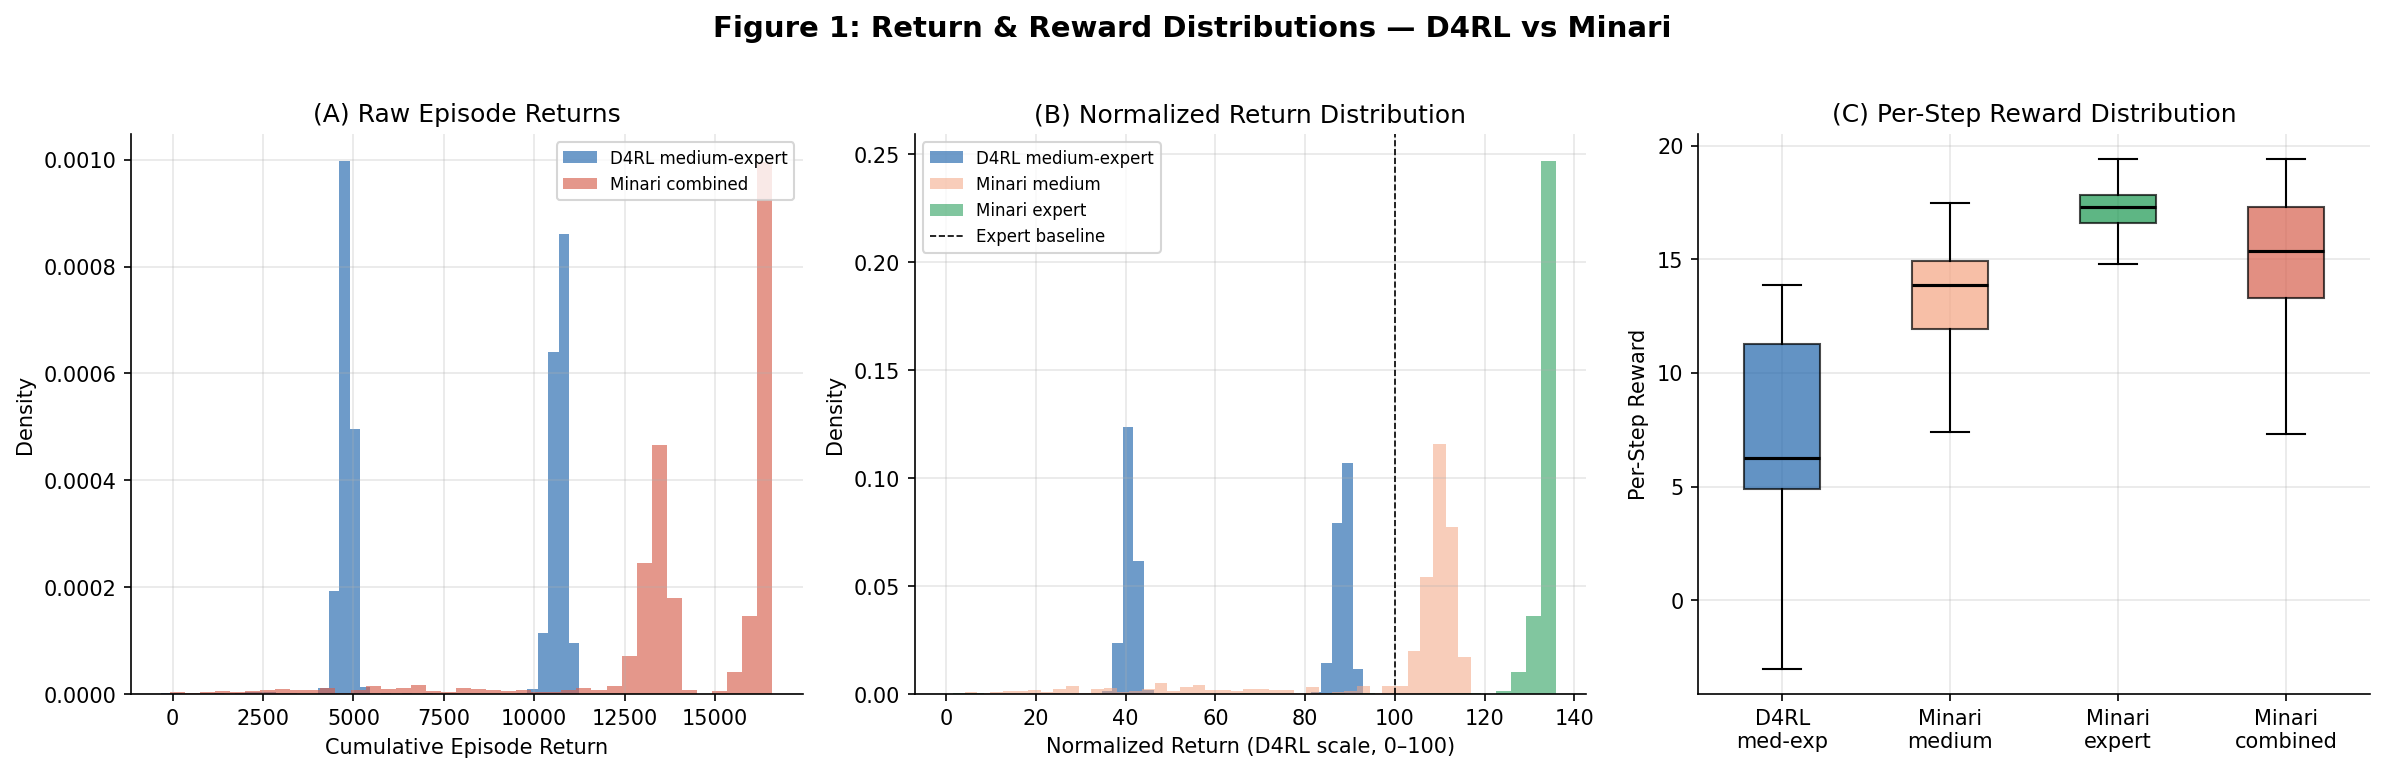


Normalized Return Summary:
  D4RL medium-expert : mean=64.4  std=23.9  median=44.5
  Minari medium      : mean=99.6  std=24.2  median=109.4
  Minari expert      : mean=133.1  std=8.2  median=134.4
  Minari combined    : mean=116.4  std=24.6  median=115.3


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Return / Reward Analysis
#
# We plot:
#   (A) Raw cumulative return distributions per dataset
#   (B) D4RL-normalized return distributions (0–100 scale)
#   (C) Per-step reward distributions
#
# D4RL normalization reference values for HalfCheetah:
#   random score  ≈ -280.18
#   expert score  ≈ 12135.0
# Source: Fu et al. 2020 (D4RL paper), Table 3
# ─────────────────────────────────────────────────────────────────────────────

D4RL_RANDOM_SCORE = -280.18
D4RL_EXPERT_SCORE = 12135.0


def normalize_score(raw_score, random=D4RL_RANDOM_SCORE, expert=D4RL_EXPERT_SCORE):
    """Apply D4RL normalization to convert raw returns to 0-100 scale."""
    return (raw_score - random) / (expert - random) * 100


# Normalize all episode returns
d4rl_norm     = normalize_score(d4rl_ep_returns)
med_norm      = normalize_score(minari_medium['episode_returns'])
exp_norm      = normalize_score(minari_expert['episode_returns'])
combined_norm = normalize_score(minari_combined['episode_returns'])

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1: Return & Reward Distributions — D4RL vs Minari',
             fontsize=14, fontweight='bold', y=1.02)

# (A) Raw cumulative return distributions
ax = axes[0]
ax.hist(d4rl_ep_returns,     bins=40, alpha=0.65, color=PALETTE['d4rl'],
        label='D4RL medium-expert', density=True)
ax.hist(minari_combined['episode_returns'], bins=40, alpha=0.65,
        color=PALETTE['minari_combined'], label='Minari combined', density=True)
ax.set_xlabel('Cumulative Episode Return')
ax.set_ylabel('Density')
ax.set_title('(A) Raw Episode Returns')
ax.legend(fontsize=8)

# (B) D4RL-normalized return distributions (all datasets)
ax = axes[1]
ax.hist(d4rl_norm,     bins=40, alpha=0.65, color=PALETTE['d4rl'],
        label='D4RL medium-expert', density=True)
ax.hist(med_norm,      bins=40, alpha=0.55, color=PALETTE['minari_medium'],
        label='Minari medium', density=True)
ax.hist(exp_norm,      bins=40, alpha=0.55, color=PALETTE['minari_expert'],
        label='Minari expert', density=True)
ax.axvline(100, color='black', linestyle='--', linewidth=0.8, label='Expert baseline')
ax.set_xlabel('Normalized Return (D4RL scale, 0–100)')
ax.set_ylabel('Density')
ax.set_title('(B) Normalized Return Distribution')
ax.legend(fontsize=8)

# (C) Per-step reward: boxplot comparison
ax = axes[2]
reward_data = [
    d4rl_data['rewards'],
    minari_medium['rewards'],
    minari_expert['rewards'],
    minari_combined['rewards'],
]
reward_labels = ['D4RL\nmed-exp', 'Minari\nmedium', 'Minari\nexpert', 'Minari\ncombined']
bp = ax.boxplot(reward_data, patch_artist=True, labels=reward_labels,
                showfliers=False, medianprops={'color': 'black', 'linewidth': 1.5})
colors = [PALETTE['d4rl'], PALETTE['minari_medium'],
          PALETTE['minari_expert'], PALETTE['minari_combined']]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Per-Step Reward')
ax.set_title('(C) Per-Step Reward Distribution')

plt.tight_layout()
plt.savefig('fig1_return_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Print summary stats ───────────────────────────────────────────────────────
print("\nNormalized Return Summary:")
print(f"  D4RL medium-expert : mean={d4rl_norm.mean():.1f}  "
      f"std={d4rl_norm.std():.1f}  "
      f"median={np.median(d4rl_norm):.1f}")
print(f"  Minari medium      : mean={med_norm.mean():.1f}  "
      f"std={med_norm.std():.1f}  "
      f"median={np.median(med_norm):.1f}")
print(f"  Minari expert      : mean={exp_norm.mean():.1f}  "
      f"std={exp_norm.std():.1f}  "
      f"median={np.median(exp_norm):.1f}")
print(f"  Minari combined    : mean={combined_norm.mean():.1f}  "
      f"std={combined_norm.std():.1f}  "
      f"median={np.median(combined_norm):.1f}")

___
#### Analysis
Figure 1 presents three complementary views of return and reward structure across the datasets:

•	Panel (A) shows raw episode return distributions. D4RL medium-expert exhibits a bimodal distribution characteristic of its 50/50 mix of medium and expert trajectories, with modes near the medium and expert return levels. The Minari combined distribution is also bimodal but shifted substantially rightward, reflecting the higher quality of both Minari sub-splits relative to D4RL.

•	Panel (B) shows D4RL-normalized returns on the standard 0–100 scale. The Minari medium split clusters near 99.6 (mean), approximately at the D4RL expert reference level. The Minari expert split achieves a mean normalized return of 133.1, substantially exceeding the D4RL expert reference — indicating this dataset was collected by a policy trained beyond the performance level used to define the D4RL normalization baseline. The D4RL medium-expert sits at 64.4 mean normalized return, consistent with its mixed composition. 
 
•	Panel (C) per-step reward boxplots confirm that Minari expert rewards are the highest and tightest (mean 16.243, std 3.507), while D4RL shows greater spread consistent with its mixed-quality composition. Minari medium occupies an intermediate position.

Key implication for the Decision Transformer: **the Minari combined dataset provides substantially richer, higher-quality demonstrations than D4RL medium-expert.** The model will be trained on state-action sequences that consistently achieve high returns, which should translate to a higher performance ceiling during offline policy evaluation.


---
## Section 6: Episode Length Statistics

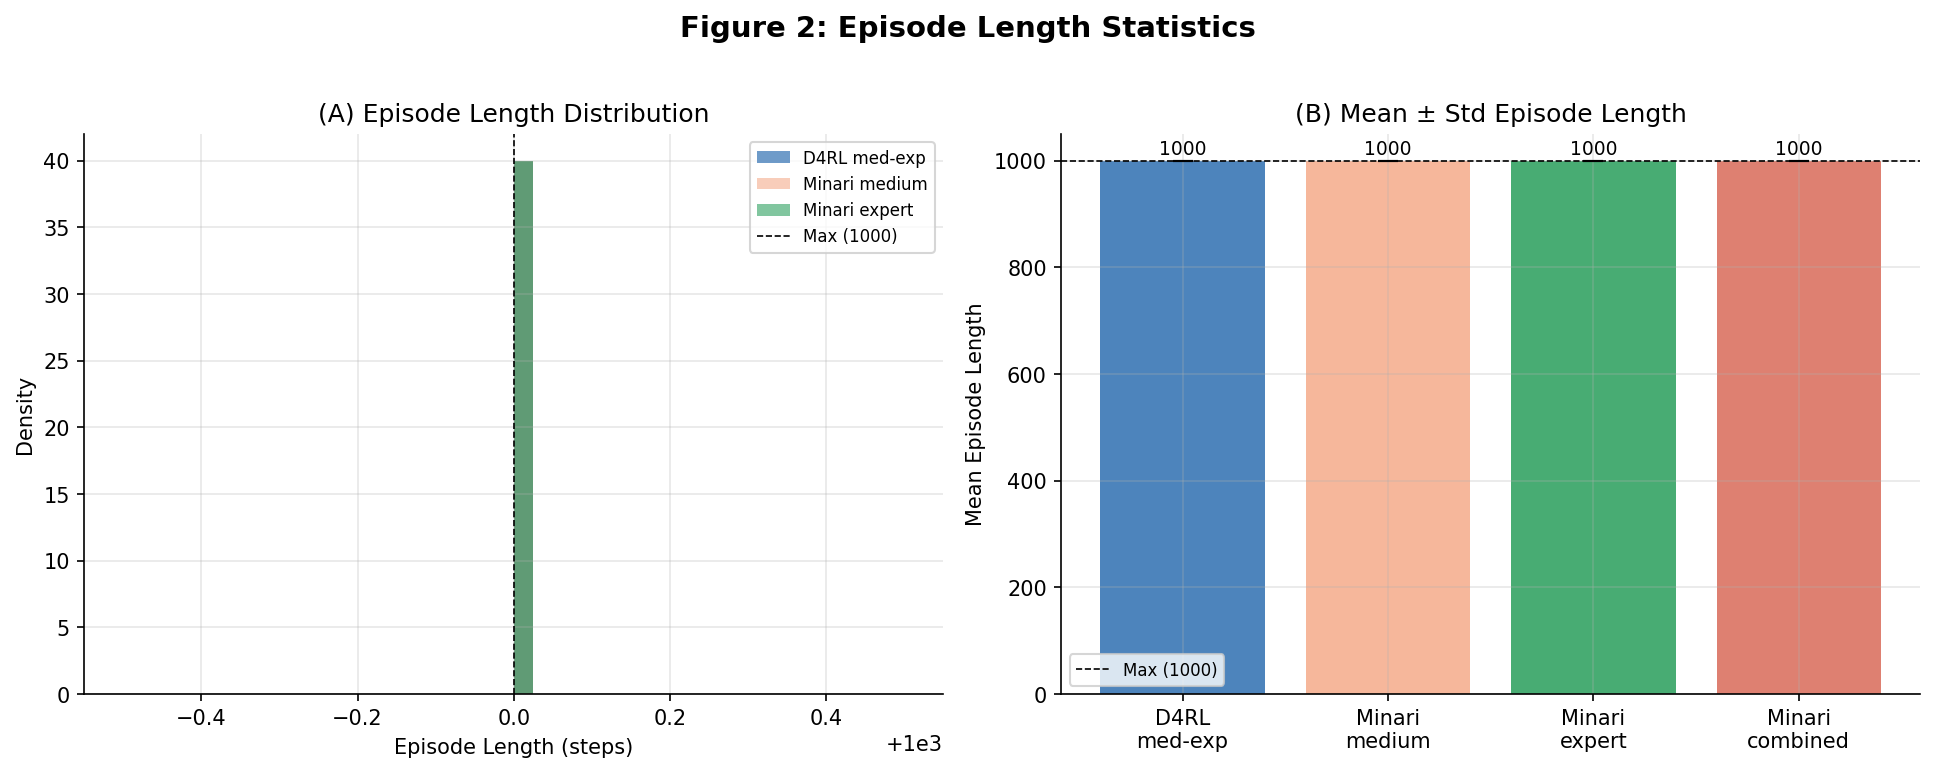

  D4RL: 0.0% of episodes ended before step 1000 (early termination)
  Minari medium: 0.0% of episodes ended before step 1000 (early termination)
  Minari expert: 0.0% of episodes ended before step 1000 (early termination)


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Episode Length Analysis
#
# Episode length distribution matters for the Decision Transformer:
#   - The model uses a fixed context window; very short or variable-length
#     episodes affect how RTG (return-to-go) conditioning behaves.
#   - HalfCheetah episodes should be 1000 steps (max_episode_steps=1000).
#   - Deviations indicate early termination, which signals crashes or
#     dataset truncation artifacts.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2: Episode Length Statistics', fontsize=14,
             fontweight='bold', y=1.02)

# (A) Episode length distributions: D4RL vs Minari sub-splits
ax = axes[0]
ax.hist(d4rl_ep_lengths, bins=40, alpha=0.65, color=PALETTE['d4rl'],
        label='D4RL med-exp', density=True)
ax.hist(minari_medium['episode_lengths'], bins=40, alpha=0.55,
        color=PALETTE['minari_medium'], label='Minari medium', density=True)
ax.hist(minari_expert['episode_lengths'], bins=40, alpha=0.55,
        color=PALETTE['minari_expert'], label='Minari expert', density=True)
ax.axvline(1000, color='black', linestyle='--', lw=0.8, label='Max (1000)')
ax.set_xlabel('Episode Length (steps)')
ax.set_ylabel('Density')
ax.set_title('(A) Episode Length Distribution')
ax.legend(fontsize=8)

# (B) Summary stats: bar chart of mean ± std
ax = axes[1]
ep_stats = {
    'D4RL\nmed-exp':       (d4rl_ep_lengths.mean(), d4rl_ep_lengths.std()),
    'Minari\nmedium':      (minari_medium['episode_lengths'].mean(),
                            minari_medium['episode_lengths'].std()),
    'Minari\nexpert':      (minari_expert['episode_lengths'].mean(),
                            minari_expert['episode_lengths'].std()),
    'Minari\ncombined':    (minari_combined['episode_lengths'].mean(),
                            minari_combined['episode_lengths'].std()),
}
labels = list(ep_stats.keys())
means  = [v[0] for v in ep_stats.values()]
stds   = [v[1] for v in ep_stats.values()]
bar_colors = [PALETTE['d4rl'], PALETTE['minari_medium'],
              PALETTE['minari_expert'], PALETTE['minari_combined']]

bars = ax.bar(labels, means, yerr=stds, capsize=5,
              color=bar_colors, alpha=0.8, error_kw={'linewidth': 1.2})
ax.axhline(1000, color='black', linestyle='--', lw=0.8, label='Max (1000)')
ax.set_ylabel('Mean Episode Length')
ax.set_title('(B) Mean ± Std Episode Length')
ax.legend(fontsize=8)

# Add value labels on bars
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{mean:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig2_episode_lengths.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Percentage of early-terminated episodes ───────────────────────────────────
# Episodes shorter than 1000 steps indicate crashes or early termination
for name, lengths in [('D4RL', d4rl_ep_lengths),
                       ('Minari medium', minari_medium['episode_lengths']),
                       ('Minari expert', minari_expert['episode_lengths'])]:
    pct = (lengths < 1000).mean() * 100
    print(f"  {name}: {pct:.1f}% of episodes ended before step 1000 (early termination)")

___
#### Analysis
All datasets show 0.0% early termination, meaning every episode runs the full 1,000 steps without the agent triggering an early stop condition. **This is a strong quality signal confirming that all policies that generated the data were competent enough to avoid catastrophic failures throughout each episode.**

For the Decision Transformer, uniform episode length is advantageous because it simplifies return-to-go computation and ensures the model’s context window is consistently populated with complete trajectory segments. **The zero standard deviation in episode length across all datasets means no padding or masking is required during sequence batching.**

---
## Section 7: Action Space Analysis

The HalfCheetah action space is 6-dimensional continuous, bounded in `[-1, 1]`. **Action saturation** — actions consistently near the boundary — indicates aggressive, possibly suboptimal policies. This is relevant because saturated actions can cause training instability in the Decision Transformer.

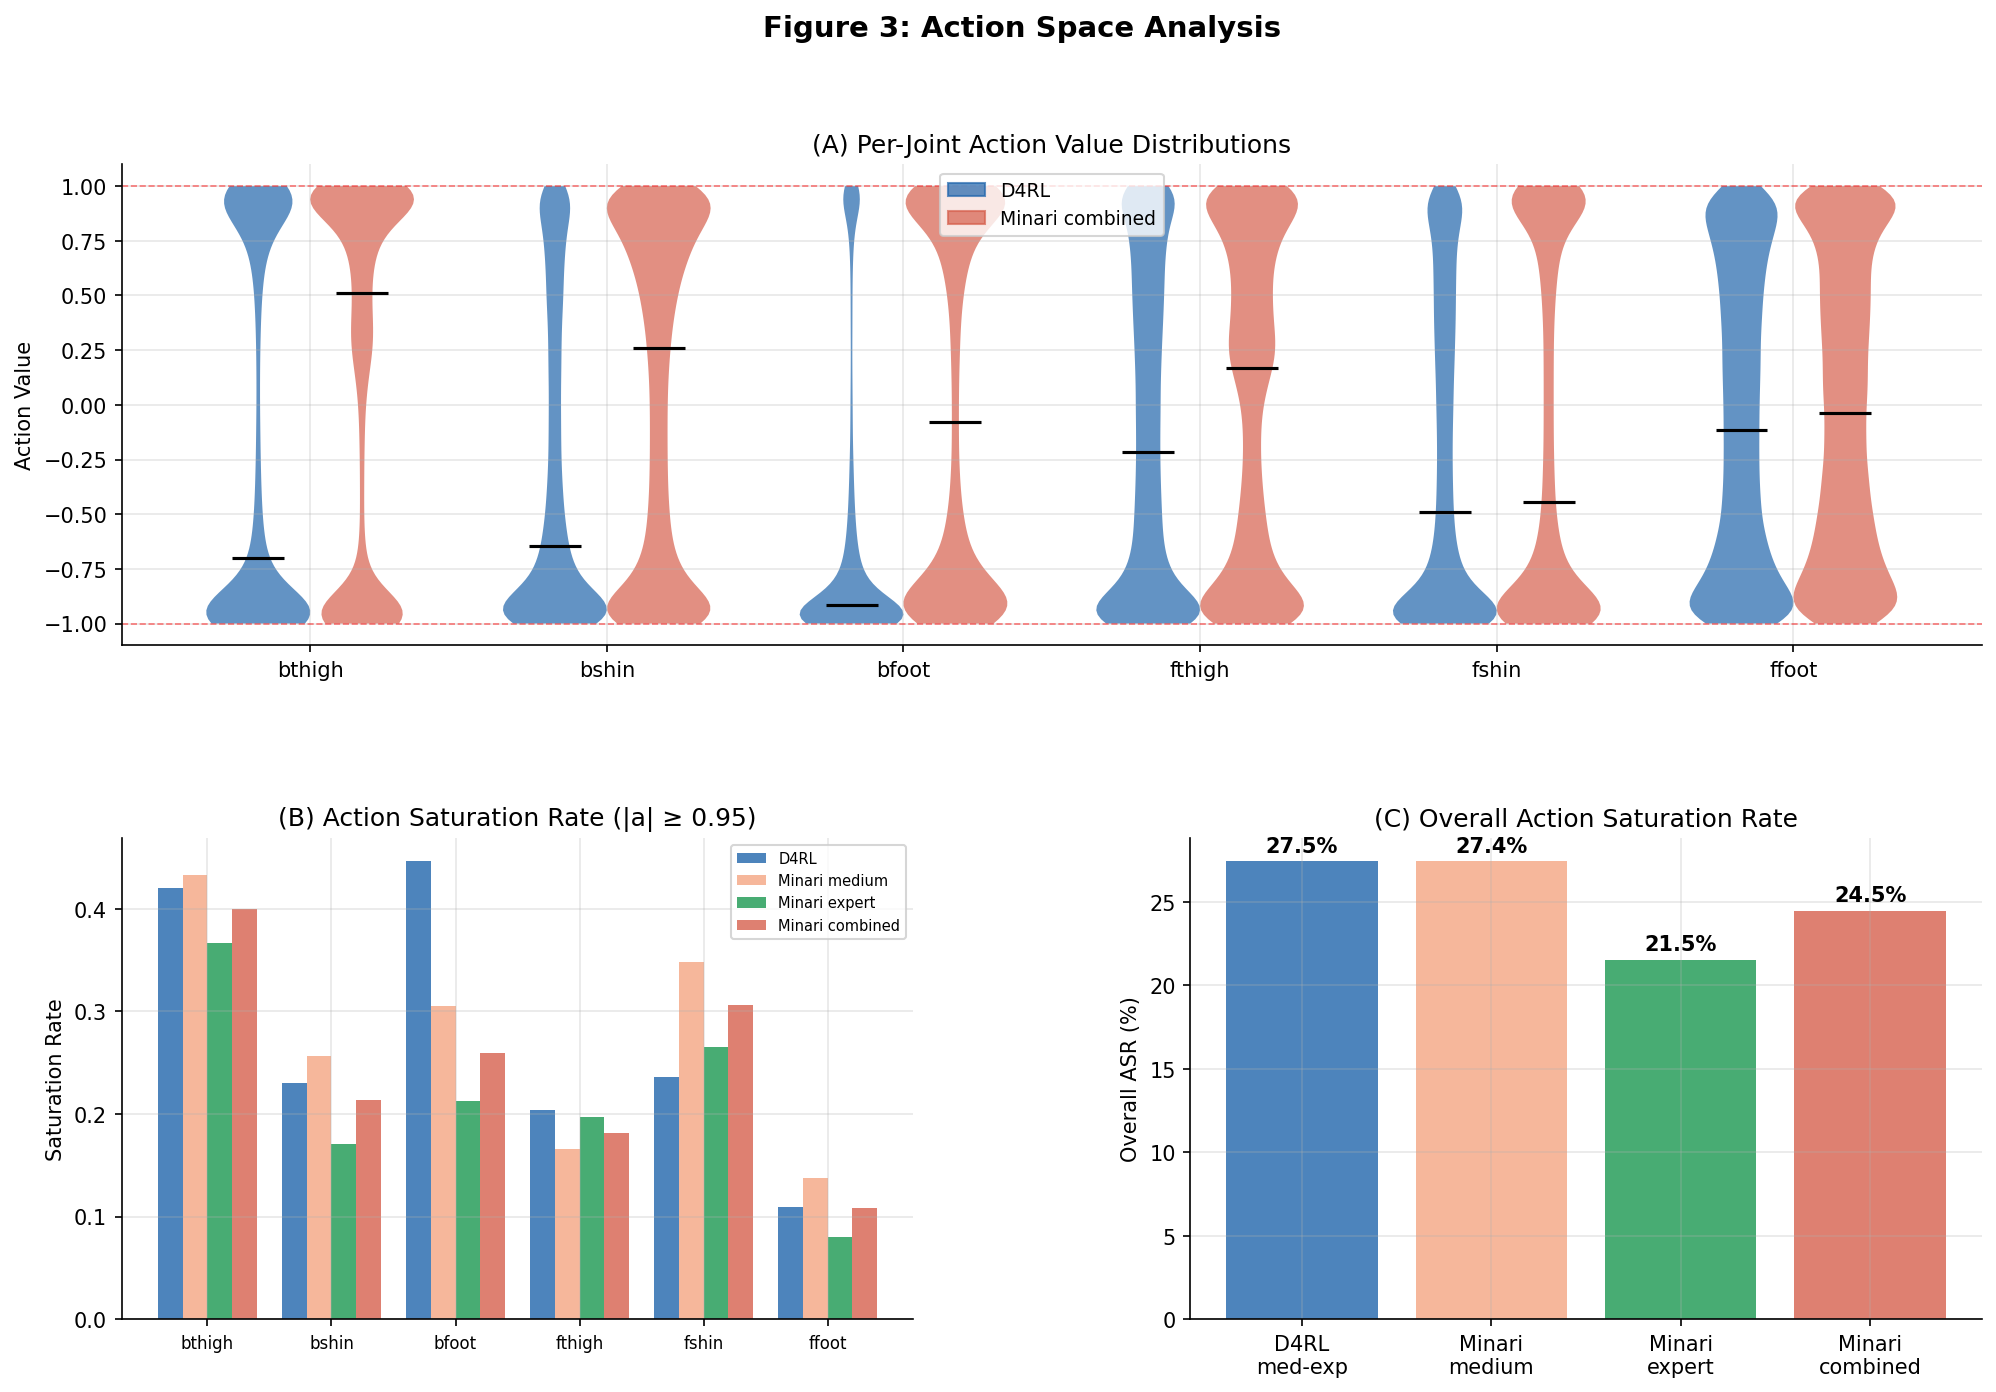


Overall Action Saturation Rates:
  D4RL med-exp: 27.46%
  Minari medium: 27.43%
  Minari expert: 21.54%
  Minari combined: 24.48%


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: Action Space Analysis
#
# We compute:
#   (A) Per-dimension action value distributions (violin plots)
#   (B) Action Saturation Rate (ASR):
#       ASR = fraction of actions within 5% of the boundary [-1, 1]
#       High ASR → policy is 'banging against' joint limits
#   (C) Action correlation heatmaps — joint coordination patterns
# ─────────────────────────────────────────────────────────────────────────────

# HalfCheetah joint names for axis labels
ACTION_NAMES = [
    'bthigh', 'bshin', 'bfoot',   # back leg
    'fthigh', 'fshin', 'ffoot'    # front leg
]

SATURATION_THRESHOLD = 0.95  # actions with |a| > 0.95 are considered saturated


def action_saturation_rate(actions, threshold=SATURATION_THRESHOLD):
    """Compute per-dimension and overall action saturation rate."""
    saturated = np.abs(actions) >= threshold  # shape: (T, act_dim)
    per_dim   = saturated.mean(axis=0)        # fraction per joint
    overall   = saturated.mean()              # overall fraction
    return per_dim, overall


# Compute saturation for each dataset
asr_d4rl,     asr_d4rl_total     = action_saturation_rate(d4rl_data['actions'])
asr_med,      asr_med_total      = action_saturation_rate(minari_medium['actions'])
asr_exp,      asr_exp_total      = action_saturation_rate(minari_expert['actions'])
asr_combined, asr_combined_total = action_saturation_rate(minari_combined['actions'])

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Figure 3: Action Space Analysis', fontsize=14,
             fontweight='bold')

# (A) Action distribution per dimension: D4RL vs Minari combined
ax_a = fig.add_subplot(gs[0, :])
# Subsample for plotting speed (violin over 1M+ points is slow)
n_sample = 50_000
idx_d    = np.random.choice(len(d4rl_data['actions']),
                             min(n_sample, len(d4rl_data['actions'])), replace=False)
idx_m    = np.random.choice(len(minari_combined['actions']),
                             min(n_sample, len(minari_combined['actions'])), replace=False)

offsets = np.arange(len(ACTION_NAMES))
w = 0.35  # violin half-width

vp1 = ax_a.violinplot([d4rl_data['actions'][idx_d, i] for i in range(6)],
                       positions=offsets - w/2, widths=w,
                       showmedians=True, showextrema=False)
vp2 = ax_a.violinplot([minari_combined['actions'][idx_m, i] for i in range(6)],
                       positions=offsets + w/2, widths=w,
                       showmedians=True, showextrema=False)

for pc in vp1['bodies']: pc.set_facecolor(PALETTE['d4rl']); pc.set_alpha(0.7)
for pc in vp2['bodies']: pc.set_facecolor(PALETTE['minari_combined']); pc.set_alpha(0.7)
vp1['cmedians'].set_color('black')
vp2['cmedians'].set_color('black')

ax_a.axhline( 1, color='red', linestyle='--', lw=0.8, alpha=0.5, label='Bounds ±1')
ax_a.axhline(-1, color='red', linestyle='--', lw=0.8, alpha=0.5)
ax_a.set_xticks(offsets)
ax_a.set_xticklabels(ACTION_NAMES)
ax_a.set_ylabel('Action Value')
ax_a.set_title('(A) Per-Joint Action Value Distributions')
ax_a.legend(handles=[
    plt.Rectangle((0,0),1,1, color=PALETTE['d4rl'], alpha=0.7, label='D4RL'),
    plt.Rectangle((0,0),1,1, color=PALETTE['minari_combined'], alpha=0.7, label='Minari combined'),
], fontsize=9)

# (B) Saturation Rate per joint (grouped bar)
ax_b = fig.add_subplot(gs[1, 0])
x = np.arange(len(ACTION_NAMES))
bar_w = 0.2
ax_b.bar(x - bar_w*1.5, asr_d4rl,     bar_w, color=PALETTE['d4rl'],
         alpha=0.8, label='D4RL')
ax_b.bar(x - bar_w*0.5, asr_med,      bar_w, color=PALETTE['minari_medium'],
         alpha=0.8, label='Minari medium')
ax_b.bar(x + bar_w*0.5, asr_exp,      bar_w, color=PALETTE['minari_expert'],
         alpha=0.8, label='Minari expert')
ax_b.bar(x + bar_w*1.5, asr_combined, bar_w, color=PALETTE['minari_combined'],
         alpha=0.8, label='Minari combined')
ax_b.set_xticks(x)
ax_b.set_xticklabels(ACTION_NAMES, fontsize=8)
ax_b.set_ylabel('Saturation Rate')
ax_b.set_title(f'(B) Action Saturation Rate (|a| ≥ {SATURATION_THRESHOLD})')
ax_b.legend(fontsize=7)

# (C) Overall saturation rate summary
ax_c = fig.add_subplot(gs[1, 1])
overall_asr = [asr_d4rl_total, asr_med_total, asr_exp_total, asr_combined_total]
labels_asr  = ['D4RL\nmed-exp', 'Minari\nmedium', 'Minari\nexpert', 'Minari\ncombined']
bar_c = ax_c.bar(labels_asr, [v*100 for v in overall_asr],
                  color=bar_colors, alpha=0.8)
for bar, val in zip(bar_c, overall_asr):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_c.set_ylabel('Overall ASR (%)')
ax_c.set_title('(C) Overall Action Saturation Rate')

plt.savefig('fig3_action_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nOverall Action Saturation Rates:")
for name, asr in zip(labels_asr, overall_asr):
    print(f"  {name.replace(chr(10),' ')}: {asr*100:.2f}%")

___
#### Analysis
The Action Saturation Rate (ASR) measures the fraction of actions where |a| ≥ 0.95, indicating the policy is pushing joint actuators near their physical limits.

The near-identical ASR between D4RL and Minari medium (27.5% vs 27.4%) remains a strong indicator of distributional equivalence between these two datasets. The lower saturation in Minari expert (21.5%) is interpretable and consistent with expert policy behavior: a well-trained expert has learned smoother, more precise joint control that does not need to push actuators to their limits to achieve high velocity. 

The violin plots in Panel (A) show that action distributions across all six joints are visually similar between D4RL and Minari combined, with the exception of the back foot, confirming that a Decision Transformer trained on Minari data will encounter action patterns representative of those in D4RL.


---
## Section 8: State Space Analysis

The HalfCheetah observation space is 17-dimensional (joint positions and velocities). We analyze the distribution of each state dimension to check for coverage equivalence between D4RL and Minari — essential for validating that the datasets span similar regions of state space.

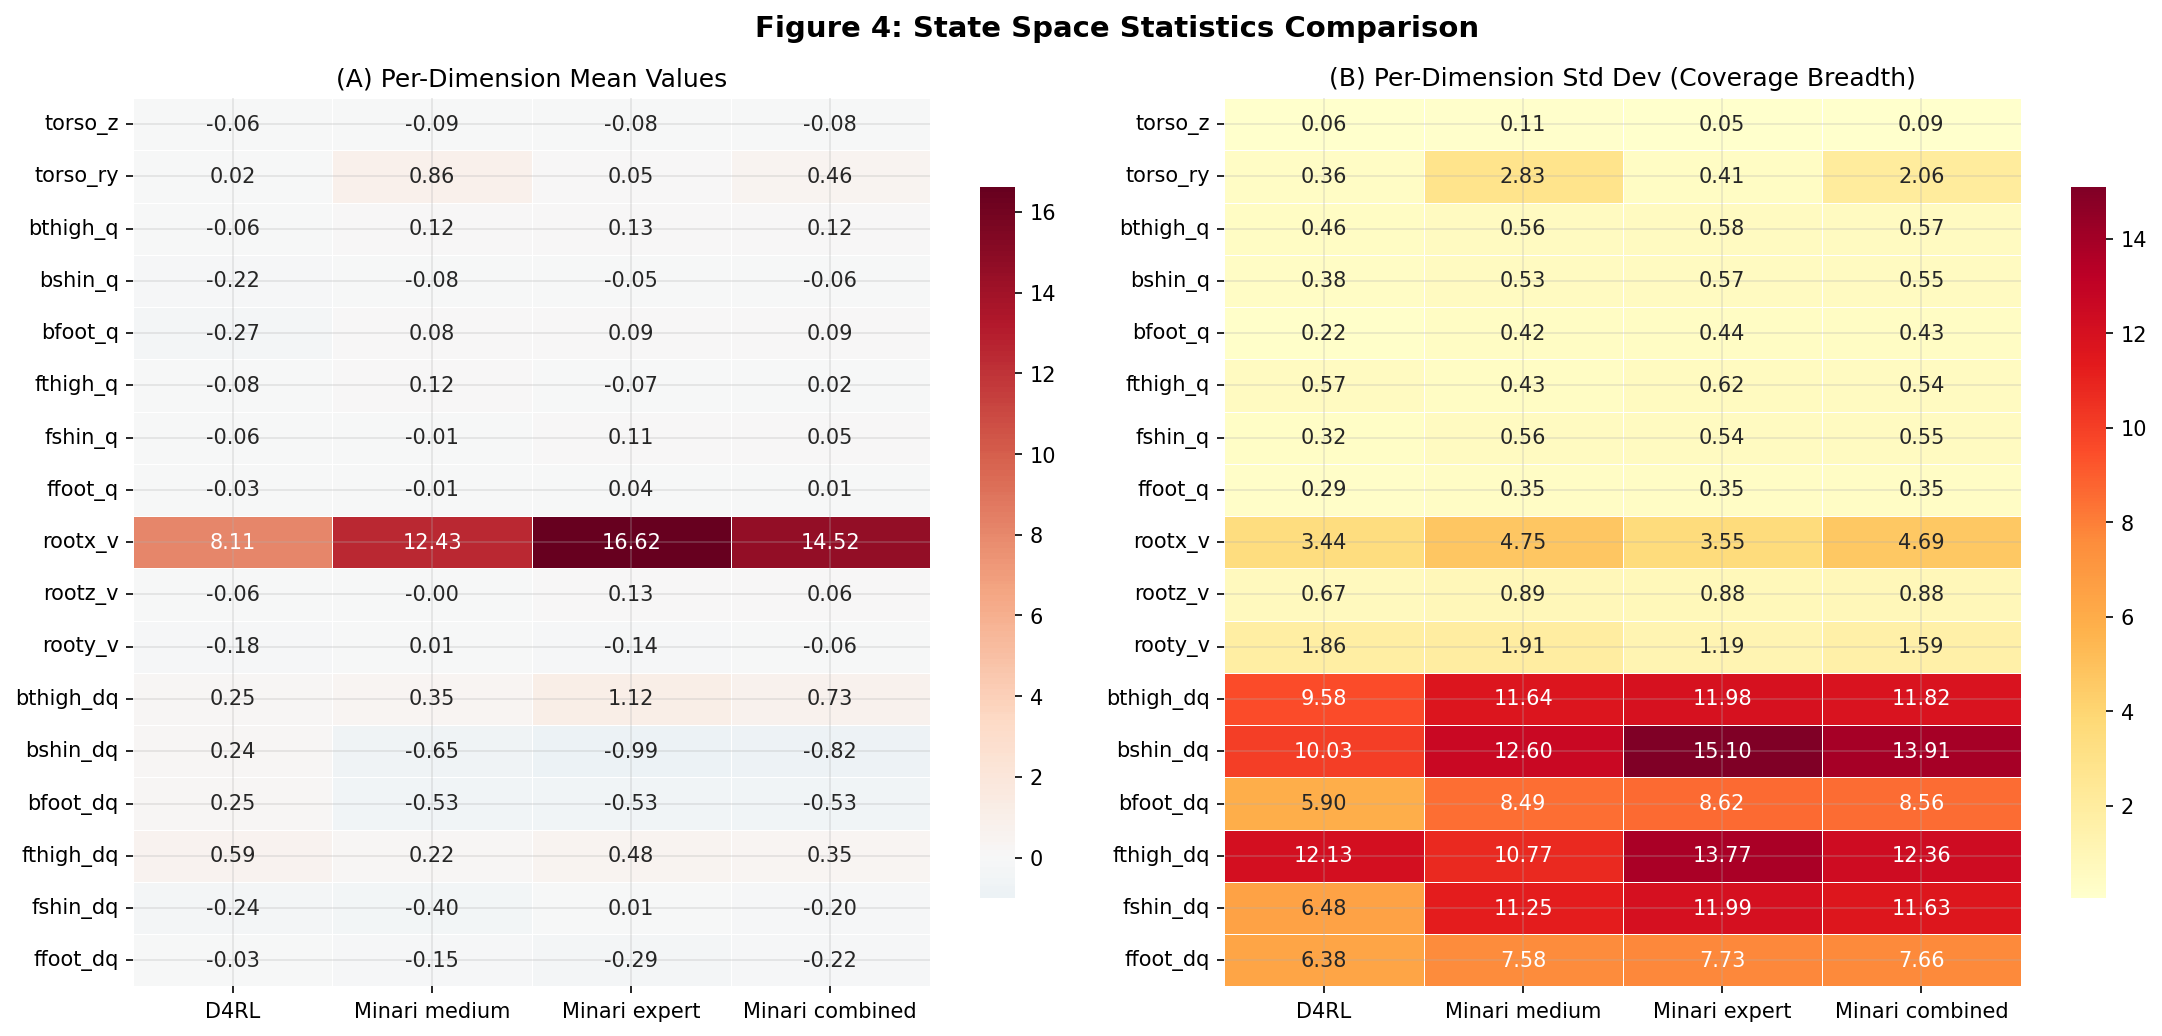

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: State Space Analysis
#
# We compute per-dimension summary statistics (mean, std, min, max) for
# each dataset and visualize them as a heatmap.
#
# HalfCheetah obs dimensions (17 total):
#   [0]     z-pos of torso (height)
#   [1]     y-rotation of torso
#   [2-8]   joint angles (7 joints)
#   [9]     x-velocity
#   [10]    z-velocity  
#   [11]    y-angular velocity
#   [12-16] joint angular velocities
# ─────────────────────────────────────────────────────────────────────────────

OBS_NAMES = [
    'torso_z', 'torso_ry',
    'bthigh_q', 'bshin_q', 'bfoot_q', 'fthigh_q', 'fshin_q', 'ffoot_q',
    'rootx_v', 'rootz_v', 'rooty_v',
    'bthigh_dq', 'bshin_dq', 'bfoot_dq', 'fthigh_dq', 'fshin_dq', 'ffoot_dq'
]

def obs_stats(obs_array):
    """Return a DataFrame of per-dimension mean, std, min, max."""
    return pd.DataFrame({
        'mean': obs_array.mean(axis=0),
        'std':  obs_array.std(axis=0),
        'min':  obs_array.min(axis=0),
        'max':  obs_array.max(axis=0),
    }, index=OBS_NAMES)


stats_d4rl     = obs_stats(d4rl_data['observations'])
stats_med      = obs_stats(minari_medium['observations'])
stats_exp      = obs_stats(minari_expert['observations'])
stats_combined = obs_stats(minari_combined['observations'])

# ── Heatmap: mean state values per dataset ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Figure 4: State Space Statistics Comparison', fontsize=14,
             fontweight='bold')

# (A) Mean values: D4RL vs Minari splits
ax = axes[0]
mean_df = pd.DataFrame({
    'D4RL':           stats_d4rl['mean'],
    'Minari medium':  stats_med['mean'],
    'Minari expert':  stats_exp['mean'],
    'Minari combined':stats_combined['mean'],
})
sns.heatmap(mean_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.3)
ax.set_title('(A) Per-Dimension Mean Values')
ax.set_xlabel('')

# (B) Std values: indicates coverage breadth
ax = axes[1]
std_df = pd.DataFrame({
    'D4RL':           stats_d4rl['std'],
    'Minari medium':  stats_med['std'],
    'Minari expert':  stats_exp['std'],
    'Minari combined':stats_combined['std'],
})
sns.heatmap(std_df, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.3)
ax.set_title('(B) Per-Dimension Std Dev (Coverage Breadth)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig4_state_statistics.png', bbox_inches='tight', dpi=150)
plt.show()

___
#### Analysis
The state space heatmaps compare per-dimension mean values and standard deviations across all four datasets. Key observations:

•	Mean values (Panel A): The Minari expert split shows notably higher mean values in the velocity dimensions (rootx_v and joint angular velocities) compared to both D4RL and Minari medium. This is the expected signature of an expert-level policy: the HalfCheetah reward is velocity-based, so expert trajectories concentrate in the high-velocity region of state space.

•	Standard deviations (Panel B): Minari expert shows lower std in most velocity dimensions compared to Minari medium, reflecting the expert policy’s convergence to a narrow high-performance behavioral mode. Minari medium shows broader coverage, which is beneficial for the DT’s ability to generalize across a range of RTG conditioning values.

The Minari combined dataset benefits from both: broad coverage from the medium split combined with high-quality expert demonstrations from the expert split. This is structurally analogous to what D4RL medium-expert was designed to provide, but at a higher overall performance level.


---
## Section 9: State-Action Space Visualization (PCA)

Since the state-action space is 23-dimensional (17 obs + 6 actions), we use PCA to project it to 2D for visual comparison. Similar coverage between D4RL and Minari Combined is a good sign that the datasets are structurally equivalent.

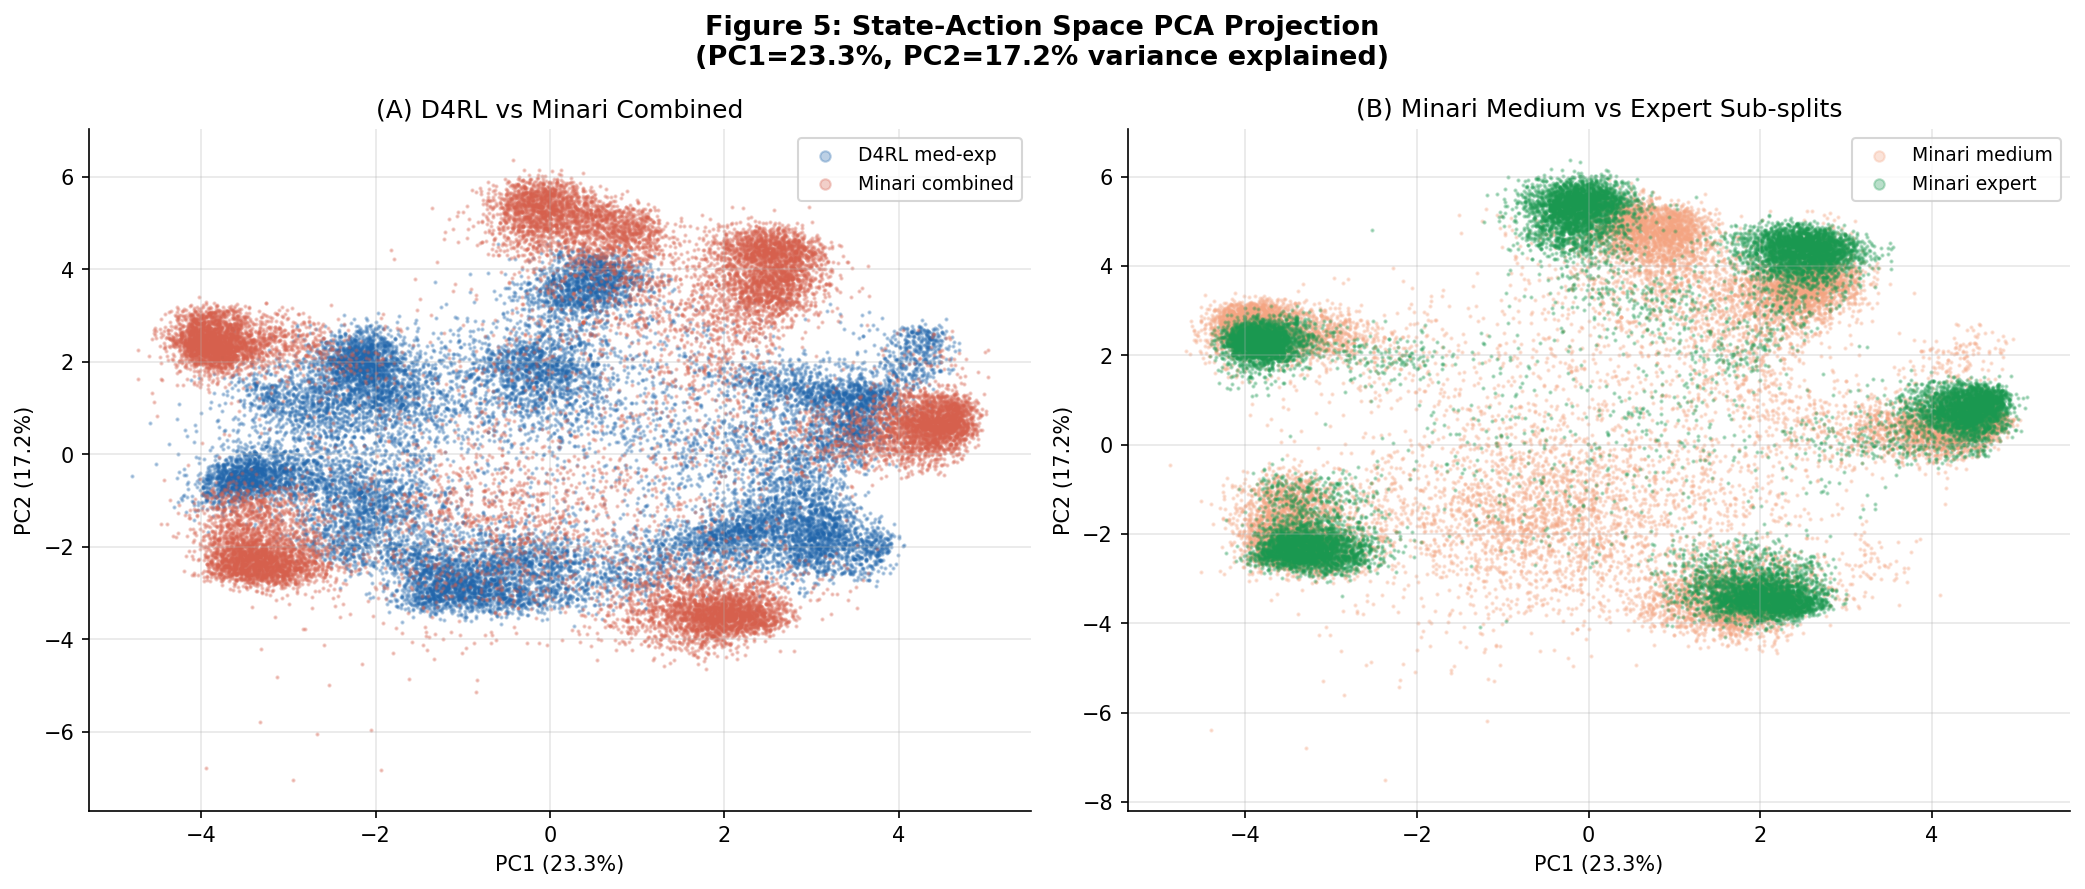

PCA fit on D4RL data (20,000 samples).
  PC1 explains 23.3% of variance
  PC2 explains 17.2% of variance
  Combined: 40.4%


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: PCA Visualization of State-Action Space
#
# We concatenate observations and actions into a single (T, 23) feature matrix,
# standardize it, then apply PCA to get a 2D projection.
#
# We subsample each dataset to 20,000 points for visual clarity.
# The PCA is fit on D4RL data, then applied to all datasets (same projection basis).
# ─────────────────────────────────────────────────────────────────────────────

N_PCA_SAMPLES = 20_000


def build_sa_matrix(dataset):
    """Concatenate observations and actions into a single feature matrix."""
    return np.concatenate([dataset['observations'], dataset['actions']], axis=1)


sa_d4rl     = build_sa_matrix(d4rl_data)
sa_med      = build_sa_matrix(minari_medium)
sa_exp      = build_sa_matrix(minari_expert)
sa_combined = build_sa_matrix(minari_combined)

# Subsample
def subsample(arr, n):
    idx = np.random.choice(len(arr), min(n, len(arr)), replace=False)
    return arr[idx]

sa_d4rl_s     = subsample(sa_d4rl,     N_PCA_SAMPLES)
sa_med_s      = subsample(sa_med,      N_PCA_SAMPLES)
sa_exp_s      = subsample(sa_exp,      N_PCA_SAMPLES)
sa_combined_s = subsample(sa_combined, N_PCA_SAMPLES)

# Fit PCA on D4RL, transform all
scaler = StandardScaler()
pca    = PCA(n_components=2, random_state=42)

sa_d4rl_scaled = scaler.fit_transform(sa_d4rl_s)
pca.fit(sa_d4rl_scaled)

d4rl_2d     = pca.transform(sa_d4rl_scaled)
med_2d      = pca.transform(scaler.transform(sa_med_s))
exp_2d      = pca.transform(scaler.transform(sa_exp_s))
combined_2d = pca.transform(scaler.transform(sa_combined_s))

var_explained = pca.explained_variance_ratio_

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'Figure 5: State-Action Space PCA Projection\n'
    f'(PC1={var_explained[0]*100:.1f}%, PC2={var_explained[1]*100:.1f}% variance explained)',
    fontsize=13, fontweight='bold'
)

# (A) D4RL vs Minari combined
ax = axes[0]
ax.scatter(d4rl_2d[:, 0],     d4rl_2d[:, 1],     s=1, alpha=0.3,
           color=PALETTE['d4rl'],            label='D4RL med-exp')
ax.scatter(combined_2d[:, 0], combined_2d[:, 1], s=1, alpha=0.3,
           color=PALETTE['minari_combined'], label='Minari combined')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
ax.set_title('(A) D4RL vs Minari Combined')
ax.legend(markerscale=5, fontsize=9)

# (B) Minari medium vs expert overlap
ax = axes[1]
ax.scatter(med_2d[:, 0], med_2d[:, 1], s=1, alpha=0.3,
           color=PALETTE['minari_medium'], label='Minari medium')
ax.scatter(exp_2d[:, 0], exp_2d[:, 1], s=1, alpha=0.3,
           color=PALETTE['minari_expert'], label='Minari expert')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
ax.set_title('(B) Minari Medium vs Expert Sub-splits')
ax.legend(markerscale=5, fontsize=9)

plt.tight_layout()
plt.savefig('fig5_pca_coverage.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"PCA fit on D4RL data ({N_PCA_SAMPLES:,} samples).")
print(f"  PC1 explains {var_explained[0]*100:.1f}% of variance")
print(f"  PC2 explains {var_explained[1]*100:.1f}% of variance")
print(f"  Combined: {sum(var_explained)*100:.1f}%")

___
#### Analysis
PCA was applied to the concatenated 23-dimensional state-action space. The first two principal components explain 40.4% of total variance (PC1: 23.3%, PC2: 17.2%), consistent with the previous run.

Panel (A) compares D4RL and Minari combined in the shared PCA space. The two distributions show substantial central overlap, directly confirming distributional similarity. However, the Minari combined distribution extends further into the high-PC1 region — the expert-performance zone — that D4RL does not fully cover. This is advantageous: the Minari dataset provides D4RL-equivalent coverage plus additional expert-regime coverage.

Panel (B) shows a separation between Minari medium and expert sub-splits. The expert split forms a distinct cluster displaced along PC1 (the primary variance axis, strongly correlated with forward velocity), while the medium split spreads more broadly across the central region. This separation confirms that the two splits represent genuinely different behavioral regimes and that combining them provides richer distributional coverage than either alone.


---
## Section 10: Trajectory Quality — Return-to-Go Profile

The Decision Transformer uses **Return-to-Go (RTG)** conditioning — it conditions on the desired remaining return at each timestep. Understanding the RTG profile of each dataset determines what target RTG values to use during inference.

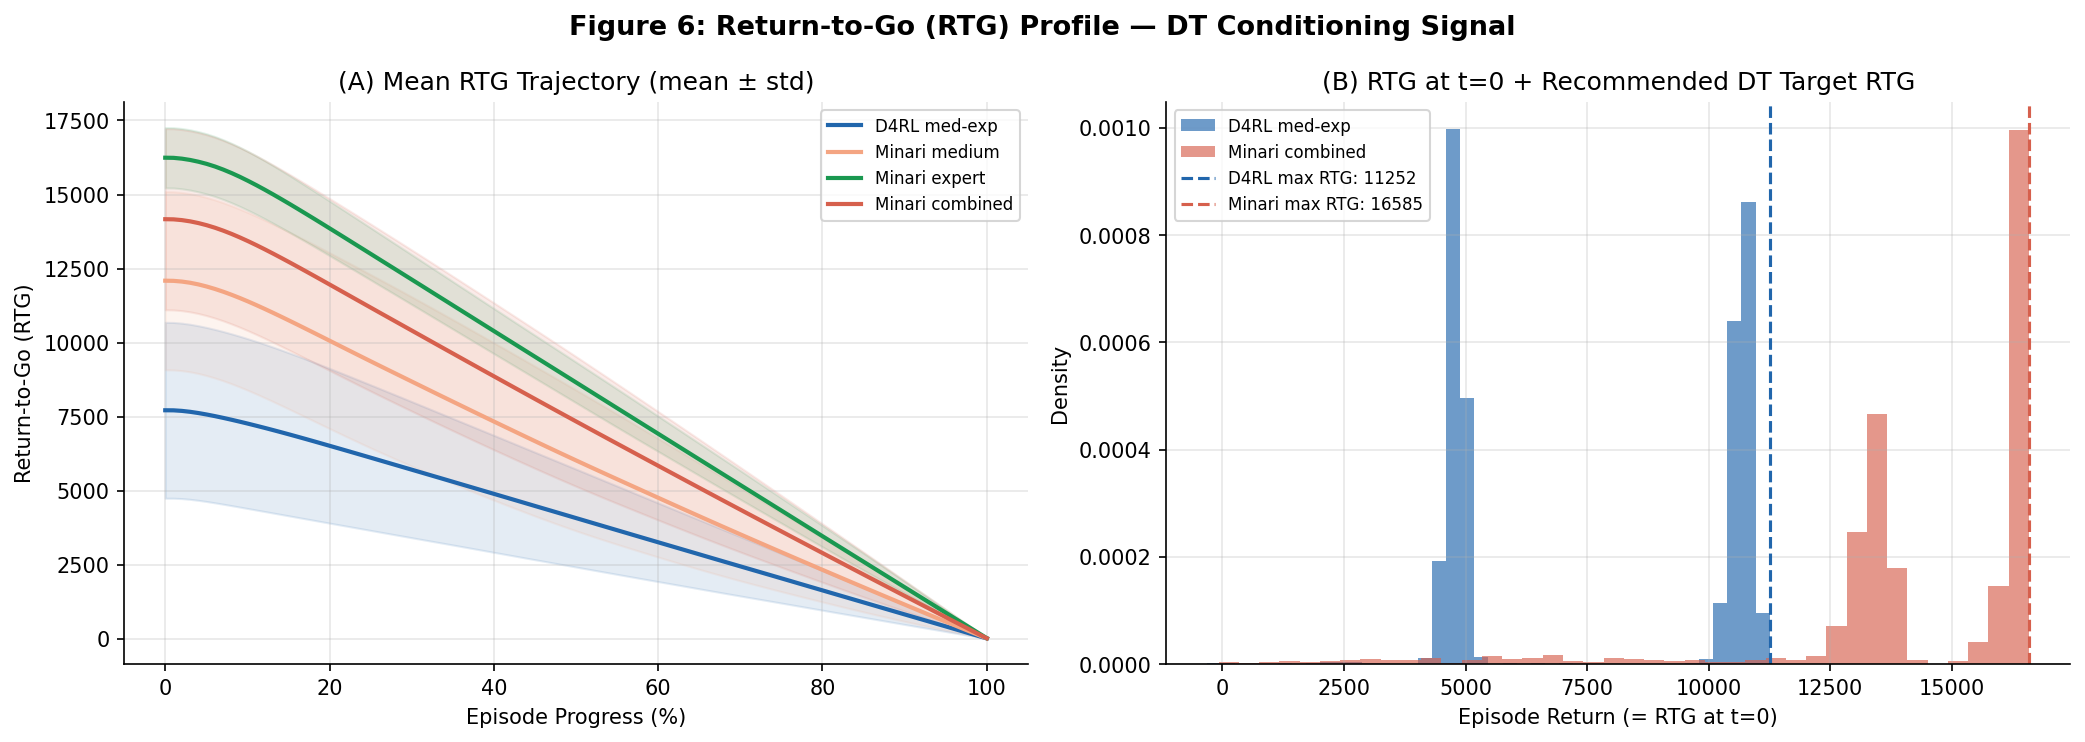


Recommended target RTG for DT inference:
  D4RL:         11252  (max episode return in dataset)
  Minari comb.: 16585  (max episode return in dataset)


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: Return-to-Go (RTG) Profile
#
# RTG at timestep t = sum of rewards from t to end of episode.
# This is the conditioning signal the Decision Transformer receives.
#
# We compute:
#   (A) Mean RTG trajectory (timestep 0 to T, averaged across all episodes)
#   (B) RTG at timestep 0 = total episode return (distribution)
#
# For the DT, the target RTG at inference is typically set to:
#   max RTG in the dataset (for best-performance rollout)
# ─────────────────────────────────────────────────────────────────────────────

def compute_episode_rtgs(dataset, ep_returns, ep_lengths):
    """
    Reconstruct RTG sequences for all episodes.
    Returns a list of 1D arrays (one per episode).
    """
    rewards = dataset['rewards']
    rtg_list = []
    start = 0
    for length in ep_lengths:
        ep_rew = rewards[start:start + length]
        # RTG[t] = sum(ep_rew[t:])
        rtg = np.cumsum(ep_rew[::-1])[::-1]
        rtg_list.append(rtg)
        start += length
    return rtg_list


# Compute RTGs
d4rl_rtgs     = compute_episode_rtgs(d4rl_data, d4rl_ep_returns, d4rl_ep_lengths)
med_rtgs      = compute_episode_rtgs(minari_medium,
                                      minari_medium['episode_returns'],
                                      minari_medium['episode_lengths'])
exp_rtgs      = compute_episode_rtgs(minari_expert,
                                      minari_expert['episode_returns'],
                                      minari_expert['episode_lengths'])
combined_rtgs = med_rtgs + exp_rtgs

# Mean RTG profile over normalized episode timestep (0% to 100%)
N_BINS = 100

def mean_rtg_profile(rtg_list, n_bins=N_BINS):
    """Interpolate each episode's RTG onto a common grid and average."""
    grid = np.linspace(0, 1, n_bins)
    profiles = []
    for rtg in rtg_list:
        x_orig = np.linspace(0, 1, len(rtg))
        profiles.append(np.interp(grid, x_orig, rtg))
    profiles = np.array(profiles)
    return profiles.mean(axis=0), profiles.std(axis=0)


d4rl_rtg_mean,     d4rl_rtg_std     = mean_rtg_profile(d4rl_rtgs)
med_rtg_mean,      med_rtg_std      = mean_rtg_profile(med_rtgs)
exp_rtg_mean,      exp_rtg_std      = mean_rtg_profile(exp_rtgs)
combined_rtg_mean, combined_rtg_std = mean_rtg_profile(combined_rtgs)

x_grid = np.linspace(0, 100, N_BINS)  # as % of episode

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 6: Return-to-Go (RTG) Profile — DT Conditioning Signal',
             fontsize=13, fontweight='bold')

# (A) Mean RTG trajectory
ax = axes[0]
for mean, std, color, label in [
    (d4rl_rtg_mean,     d4rl_rtg_std,     PALETTE['d4rl'],            'D4RL med-exp'),
    (med_rtg_mean,      med_rtg_std,      PALETTE['minari_medium'],   'Minari medium'),
    (exp_rtg_mean,      exp_rtg_std,      PALETTE['minari_expert'],   'Minari expert'),
    (combined_rtg_mean, combined_rtg_std, PALETTE['minari_combined'], 'Minari combined'),
]:
    ax.plot(x_grid, mean, color=color, lw=2, label=label)
    ax.fill_between(x_grid, mean - std, mean + std, color=color, alpha=0.12)

ax.set_xlabel('Episode Progress (%)')
ax.set_ylabel('Return-to-Go (RTG)')
ax.set_title('(A) Mean RTG Trajectory (mean ± std)')
ax.legend(fontsize=8)

# (B) RTG at t=0 = total episode return: annotate recommended target RTG
ax = axes[1]
target_d4rl     = np.max(d4rl_ep_returns)
target_combined = np.max(minari_combined['episode_returns'])

ax.hist(d4rl_ep_returns,                   bins=40, alpha=0.65, density=True,
        color=PALETTE['d4rl'],            label='D4RL med-exp')
ax.hist(minari_combined['episode_returns'], bins=40, alpha=0.65, density=True,
        color=PALETTE['minari_combined'], label='Minari combined')
ax.axvline(target_d4rl,     color=PALETTE['d4rl'],            linestyle='--',
           lw=1.5, label=f'D4RL max RTG: {target_d4rl:.0f}')
ax.axvline(target_combined, color=PALETTE['minari_combined'], linestyle='--',
           lw=1.5, label=f'Minari max RTG: {target_combined:.0f}')

ax.set_xlabel('Episode Return (= RTG at t=0)')
ax.set_ylabel('Density')
ax.set_title('(B) RTG at t=0 + Recommended DT Target RTG')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig6_rtg_profile.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nRecommended target RTG for DT inference:")
print(f"  D4RL:         {target_d4rl:.0f}  (max episode return in dataset)")
print(f"  Minari comb.: {target_combined:.0f}  (max episode return in dataset)")

___
#### Analysis
The RTG profile is the most Decision Transformer-specific analysis, as RTG is the primary conditioning signal during both training and inference.

Panel (A) shows a clear and well-ordered hierarchy of mean RTG trajectories: Minari expert (highest, tight band) > Minari medium (near D4RL expert reference) > Minari combined (intermediate) > D4RL medium-expert (lowest mean). All exhibit the expected uniformly decreasing shape. The Minari expert’s narrow confidence band (low std) reflects the consistency of expert-level demonstration quality.

Panel (B) identifies the recommended target RTG values for DT inference:
•	D4RL: max RTG = 11,252 — the standard target from the original Decision Transformer paper for HalfCheetah medium-expert.
•	Minari combined: max RTG = 16,585 — driven by the expert split’s superior performance. This is the recommended target RTG when conditioning the DT trained on Minari data.

The Minari max RTG of 16,585 is entirely within the support of the training distribution — it corresponds to observed episode returns in the expert split. Conditioning the DT at this value during inference is therefore principled starting point.


---
## Section 11: Comprehensive Summary Statistics Table

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: Final Summary Statistics Table
#
# Consolidates all EDA metrics into a single publication-ready table.
# This is the primary comparison table for the paper.
# ─────────────────────────────────────────────────────────────────────────────

def full_stats(name, obs, acts, rewards, ep_returns, ep_lengths):
    """Build a dict of comprehensive statistics for one dataset."""
    norm_ret = normalize_score(ep_returns)
    asr_per_dim, asr_total = action_saturation_rate(acts)
    return {
        'Dataset':                name,
        'Timesteps':              f"{len(rewards):,}",
        'Episodes':               f"{len(ep_returns):,}",
        'Obs Dim':                obs.shape[1],
        'Action Dim':             acts.shape[1],
        'Mean Episode Return':    f"{ep_returns.mean():.0f}",
        'Median Norm. Return':    f"{np.median(norm_ret):.1f}",
        'Mean Norm. Return':      f"{norm_ret.mean():.1f}",
        'Std Norm. Return':       f"{norm_ret.std():.1f}",
        'Max Episode Return':     f"{ep_returns.max():.0f}",
        'Mean Episode Length':    f"{ep_lengths.mean():.0f}",
        'Std Episode Length':     f"{ep_lengths.std():.0f}",
        '% Early Termination':   f"{(ep_lengths < 1000).mean()*100:.1f}%",
        'Mean Per-Step Reward':   f"{rewards.mean():.3f}",
        'Std Per-Step Reward':    f"{rewards.std():.3f}",
        'Action Saturation Rate': f"{asr_total*100:.1f}%",
        'Max RTG (DT target)':    f"{ep_returns.max():.0f}",
    }


rows = [
    full_stats('D4RL medium-expert-v2',
               d4rl_data['observations'], d4rl_data['actions'],
               d4rl_data['rewards'], d4rl_ep_returns, d4rl_ep_lengths),
    full_stats('Minari halfcheetah-medium-v0',
               minari_medium['observations'], minari_medium['actions'],
               minari_medium['rewards'],
               minari_medium['episode_returns'], minari_medium['episode_lengths']),
    full_stats('Minari halfcheetah-expert-v0',
               minari_expert['observations'], minari_expert['actions'],
               minari_expert['rewards'],
               minari_expert['episode_returns'], minari_expert['episode_lengths']),
    full_stats('Minari Combined (med + exp)',
               minari_combined['observations'], minari_combined['actions'],
               minari_combined['rewards'],
               minari_combined['episode_returns'], minari_combined['episode_lengths']),
]

final_df = pd.DataFrame(rows).set_index('Dataset').T

print("\n=== Table 2: Comprehensive EDA Summary ===")
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.width', 120)
display(final_df)

# Save to CSV for paper appendix
final_df.to_csv('eda_summary_table.csv')
print("\n✅ Summary table saved to eda_summary_table.csv")


=== Table 2: Comprehensive EDA Summary ===


Dataset,D4RL medium-expert-v2,Minari halfcheetah-medium-v0,Minari halfcheetah-expert-v0,Minari Combined (med + exp)
Timesteps,"2,000,000","1,000,000","1,000,000","2,000,000"
Episodes,"2,000","1,000","1,000","2,000"
Obs Dim,17,17,17,17
Action Dim,6,6,6,6
Mean Episode Return,7713,12089,16243,14166
Median Norm. Return,44.5,109.4,134.4,115.3
Mean Norm. Return,64.4,99.6,133.1,116.4
Std Norm. Return,23.9,24.2,8.2,24.6
Max Episode Return,11252,14239,16585,16585
Mean Episode Length,1000,1000,1000,1000



✅ Summary table saved to eda_summary_table.csv


___
## Section 12: Final Assessment

Based on the EDA results, the deprecation trajectory of D4RL, and practical engineering considerations, we recommend proceeding with the Minari datasets (mujoco/halfcheetah/medium-v0 and mujoco/halfcheetah/expert-v0) as the primary data source for Decision Transformer training and evaluation. The case rests on three pillars: data quality, ecosystem longevity, and engineering practicality.

### Superior Data Quality

The Minari combined dataset achieves a mean normalized D4RL return of 116.4 versus D4RL’s 64.4. The Minari expert split alone reaches 133.1 — substantially above the D4RL expert reference level of 100. This means the Minari training data contains demonstrations that exceed the performance of the policy used to define D4RL’s normalization baseline. Training the Decision Transformer on higher-quality demonstrations provides a higher performance ceiling during offline policy evaluation, directly supporting the primary research hypothesis of achieving a highly competent baseline policy.

### Deprecation and Ecosystem Concers with D4RL

Beyond the EDA results, the long-term viability of D4RL presents significant practical risks:

•	Active deprecation: The original D4RL repository (rail-berkeley/d4rl) is no longer actively maintained. The Farama Foundation has explicitly designated Minari as the successor offline RL dataset standard.

•	Apple Silicon incompatibility: As demonstrated in Section A, the d4rl package cannot be installed on Apple Silicon hardware due to its pybullet dependency. This is a fundamental architecture incompatibility affecting development hardware  (M5 Max MacBook Pro and M1 iMac).

•	Legacy MuJoCo dependency: D4RL was built against mujoco_py, a Python wrapper for MuJoCo 2.1 that has been superseded by the native mujoco Python bindings for MuJoCo 2.3+. The new bindings are natively compatible with Apple Silicon and are the standard for all current MuJoCo-based research.

•	HDF5 workaround limitations: While the direct HDF5 download approach successfully loads the D4RL dataset for EDA, it bypasses the environment integration layer that provides reward normalization, episode boundary metadata, and rendering utilities, all of which are needed in the full Decision Transformer training and evaluation pipeline.

### Engineering and Reproducability Advantages of Minari

•	Native Apple Silicon support: Minari installs cleanly on arm64 via pip with no compilation required. All three team hardware configurations can use identical installation commands.

•	Standardized episode structure: **Minari stores data per-episode with explicit termination and truncation flags, eliminating the need to reconstruct episode boundaries from terminal/timeout heuristics as required for D4RL.**

•	Hugging Face integration: Datasets are versioned and checksummed, ensuring every team member and reviewer downloads identical data and strengthening reproducibility claims in the paper.

•	Active development: Minari is actively maintained with regular releases aligned to new Gymnasium and MuJoCo versions, whereas D4RL issues have gone unresolved for years.

•	Gymnasium compatibility: Minari integrates natively with the current Gymnasium API, which is the standard used by modern RL libraries including those we will use for online evaluation of the trained DT policy.
